<a href="https://colab.research.google.com/github/nuurceng/CXR_26/blob/main/raw%26roi_efficientb_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/final_data

In [ ]:
!pip install efficientnet_pytorch -q

  Preparing metadata (setup.py) ... done


In [ ]:
import os, zipfile, torch, wandb, datetime, shutil
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from transformers import SwinForImageClassification
from google.colab import drive, runtime
from efficientnet_pytorch import EfficientNet

model_variant = "EfNet-B7" # Model b0-b7
data_type = "RAW"         # RAW & ROI
model_full_name = f"{model_variant}-{data_type}"

size_name = model_variant.lower().replace("efnet", "efficientnet")
img_size = EfficientNet.get_image_size(size_name)
print(f"🎯 {model_variant} için otomatik belirlenen çözünürlük: {img_size}")

base_drive_path = "/content/drive/MyDrive/segmantation_chest_x-rays/lungsClassification-raw"
cm_drive_path = "/content/drive/MyDrive/segmantation_chest_x-rays/lungsClassificationCM-raw"
os.makedirs(base_drive_path, exist_ok=True)
os.makedirs(cm_drive_path, exist_ok=True)


🎯 EfNet-B7 için otomatik belirlenen çözünürlük: 600


In [ ]:
extract_path = '/content/final_data'
if not os.path.exists(extract_path):
    print("🚀 Veri seti yerel diske çıkarılıyor...")
    zip_path = '/content/drive/MyDrive/segmantation_chest_x-rays/FINAL_RAW_CLASSIFICATION_DATASET_20260420.zip'
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
print("🚀 Veri seti yerel diske çıkarılması tamamlandı...")

🚀 Veri seti yerel diske çıkarılıyor...
🚀 Veri seti yerel diske çıkarılması tamamlandı...


In [ ]:
train_dir = os.path.join(extract_path, 'train')
val_dir = os.path.join(extract_path, 'val')
test_dir = os.path.join(extract_path, 'test')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size)),#
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
      'test': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, data_transforms['val'])
test_dataset = datasets.ImageFolder(test_dir, data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
def plot_and_save_cm(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45, ax=ax, values_format='d')#cmap='viridis',
    plt.title(title)
    plt.tight_layout()
    local_path = f"/content/{filename}"
    plt.savefig(local_path)
    plt.close()

    shutil.copyfile(local_path, os.path.join(cm_drive_path, filename))
    return local_path

wandb.login(key="key")
current_time = datetime.datetime.now().strftime("%H%M%S")
run_name = f"{model_full_name}-20Epoch-{current_time}"

run = wandb.init(
    project="Lung-Segmentation_Classification-raw",
    name=run_name,
    config={"model": model_variant, "data": data_type, "lr": 1e-4, "epochs": 20}
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if "EfNet" in model_variant:
    func_name = model_variant.lower().replace("efnet-", "efficientnet_")

    if "efnet" in model_variant.lower() and "_" not in func_name:
        func_name = model_variant.lower().replace("efnet", "efficientnet_")

    print(f"🔄 PyTorch'tan yüklenen fonksiyon: {func_name}")

    model_func = getattr(models, func_name)
    model = model_func(weights="DEFAULT")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)
else:
    pass

model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

best_f1 = 0.0
class_names = ['COVID', 'NORMAL', 'PNEUMONIA', 'TUBERCULOSIS']

for epoch in range(20):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/20 [Train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_train_preds.extend(preds.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    t_acc = accuracy_score(all_train_labels, all_train_preds)
    t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(all_train_labels, all_train_preds, average='macro')

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels, all_val_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            all_val_probs.extend(probs.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    v_acc = accuracy_score(all_val_labels, all_val_preds)
    v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(all_val_labels, all_val_preds, average='macro')

    scheduler.step(v_f1)
    curr_lr = optimizer.param_groups[0]['lr']

    # ---
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": avg_train_loss, "train/acc": t_acc, "train/f1": t_f1,
        "train/precision": t_prec, "train/recall": t_rec,
        "val/loss": avg_val_loss, "val/acc": v_acc, "val/f1": v_f1,
        "val/precision": v_prec, "val/recall": v_rec,
        "lr": curr_lr,
        "conf_mat_wandb": wandb.plot.confusion_matrix(probs=None, y_true=all_val_labels, preds=all_val_preds, class_names=class_names),
        "roc": wandb.plot.roc_curve(all_val_labels, np.array(all_val_probs), labels=class_names)
    })

    # ---
    print(f"\n" + "="*95)
    print(f"🚩 EPOCH {epoch+1} ÖZETİ (LR: {curr_lr:.2e})")
    print("-" * 95)
    print(f"TRAIN | Loss: {avg_train_loss:.4f} | Acc: {t_acc:.4f} | F1: {t_f1:.4f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f}")
    print(f"VAL   | Loss: {avg_val_loss:.4f} | Acc: {v_acc:.4f} | F1: {v_f1:.4f} | Prec: {v_prec:.4f} | Rec: {v_rec:.4f}")
    print("="*95 + "\n")

    # CHECKPOINT
    if v_f1 > best_f1:
        best_f1 = v_f1
        model_save_name = f"best_model_{model_full_name}.pth"
        local_model_path = f"/content/{model_save_name}"
        torch.save(model.state_dict(), local_model_path)
        shutil.copyfile(local_model_path, os.path.join(base_drive_path, model_save_name))
        print(f"⭐ En iyi model güncellendi! (F1: {best_f1:.4f} - Model: {model_save_name})")

# ---
print("\n🏆 EĞİTİM TAMAMLANDI. EN İYİ MODEL YÜKLENEREK FİNAL ANALİZ BAŞLIYOR...")
model.load_state_dict(torch.load(os.path.join(base_drive_path, f"best_model_{model_full_name}.pth")))
model.eval()

def final_report_and_visuals(loader, name):
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"{name} Analiz Ediliyor"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1); _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy()); all_preds.extend(preds.cpu().numpy()); all_probs.extend(probs.cpu().numpy())

    # A. Classification Report
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    separator = "-" * 60
    final_text_report = f"\n📊 {name} SINIFLANDIRMA RAPORU\n{separator}\n{report}\n{separator}\n"
    print(final_text_report)

    run.summary[f"final_report_{name.lower().replace(' ', '_')}"] = final_text_report

    report_file_name = f"{model_full_name}_{name.replace(' ', '_')}_report.txt"
    report_file_path = os.path.join(base_drive_path, report_file_name)

    with open(report_file_path, "w", encoding="utf-8") as f:
        f.write(final_text_report)

    # B. Confusion Matrix
    cm_filename = f"CM_{model_full_name}_{name.replace(' ', '_')}.png"
    local_cm = plot_and_save_cm(all_labels, all_preds, class_names, f"{model_full_name} {name} CM", cm_filename)
    wandb.log({f"final_cm_{name.lower().replace(' ', '_')}": wandb.Image(local_cm)})

    # C. ROC Curve
    wandb.log({
        f"final_roc_{name.lower().replace(' ', '_')}": wandb.plot.roc_curve(
            all_labels,
            np.array(all_probs),
            labels=class_names,
            title=f"ROC Curve - {model_full_name} - {name}"
        )
    })


final_report_and_visuals(val_loader, "VALIDATION SETI")
final_report_and_visuals(test_loader, "TEST SETI")

artifact = wandb.Artifact(f"results-{model_full_name}", type="evaluation_results")

artifact.add_file(os.path.join(base_drive_path, f"best_model_{model_full_name}.pth"))

val_cm_name = f"CM_{model_full_name}_VALIDATION_SETI.png"
test_cm_name = f"CM_{model_full_name}_TEST_SETI.png"

if os.path.exists(os.path.join(cm_drive_path, val_cm_name)):
    artifact.add_file(os.path.join(cm_drive_path, val_cm_name))
if os.path.exists(os.path.join(cm_drive_path, test_cm_name)):
    artifact.add_file(os.path.join(cm_drive_path, test_cm_name))

val_rep_name = f"{model_full_name}_VALIDATION_SETI_report.txt"
test_rep_name = f"{model_full_name}_TEST_SETI_report.txt"

if os.path.exists(os.path.join(base_drive_path, val_rep_name)):
    artifact.add_file(os.path.join(base_drive_path, val_rep_name))
if os.path.exists(os.path.join(base_drive_path, test_rep_name)):
    artifact.add_file(os.path.join(base_drive_path, test_rep_name))

run.log_artifact(artifact)
print(f"📦 Artifact güncellendi: Model, CM'ler ve Raporlar WandB'ye paketlendi!")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nurkaraca0638 (nurkaraca0638-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


🔄 PyTorch'tan yüklenen fonksiyon: efficientnet_b7
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 156MB/s]
Epoch 1/20 [Train]: 100%|██████████| 444/444 [03:42<00:00,  1.99it/s, loss=0.1124]



🚩 EPOCH 1 ÖZETİ (LR: 1.00e-04)
-----------------------------------------------------------------------------------------------
TRAIN | Loss: 0.2434 | Acc: 0.9192 | F1: 0.9155 | Prec: 0.9167 | Rec: 0.9146
VAL   | Loss: 0.0804 | Acc: 0.9734 | F1: 0.9725 | Prec: 0.9724 | Rec: 0.9728

⭐ En iyi model güncellendi! (F1: 0.9725 - Model: best_model_EfNet-B7-RAW.pth)


Epoch 2/20 [Train]: 100%|██████████| 444/444 [03:40<00:00,  2.01it/s, loss=0.1123]


...


🚩 EPOCH 20 ÖZETİ (LR: 1.00e-05)
-----------------------------------------------------------------------------------------------
TRAIN | Loss: 0.0012 | Acc: 0.9999 | F1: 0.9998 | Prec: 0.9999 | Rec: 0.9998
VAL   | Loss: 0.0484 | Acc: 0.9911 | F1: 0.9911 | Prec: 0.9912 | Rec: 0.9911


🏆 EĞİTİM TAMAMLANDI. EN İYİ MODEL YÜKLENEREK FİNAL ANALİZ BAŞLIYOR...


VALIDATION SETI Analiz Ediliyor: 100%|██████████| 127/127 [00:23<00:00,  5.44it/s]



📊 VALIDATION SETI SINIFLANDIRMA RAPORU
------------------------------------------------------------
              precision    recall  f1-score   support

       COVID     0.9927    0.9927    0.9927       413
      NORMAL     0.9900    0.9900    0.9900       498
   PNEUMONIA     0.9894    0.9947    0.9920       561
TUBERCULOSIS     1.0000    0.9946    0.9973       556

    accuracy                         0.9931      2028
   macro avg     0.9930    0.9930    0.9930      2028
weighted avg     0.9931    0.9931    0.9931      2028

------------------------------------------------------------



TEST SETI Analiz Ediliyor: 100%|██████████| 64/64 [00:11<00:00,  5.43it/s]



📊 TEST SETI SINIFLANDIRMA RAPORU
------------------------------------------------------------
              precision    recall  f1-score   support

       COVID     1.0000    1.0000    1.0000       207
      NORMAL     0.9920    0.9880    0.9900       250
   PNEUMONIA     0.9894    0.9929    0.9911       281
TUBERCULOSIS     1.0000    1.0000    1.0000       279

    accuracy                         0.9951      1017
   macro avg     0.9953    0.9952    0.9953      1017
weighted avg     0.9951    0.9951    0.9951      1017

------------------------------------------------------------

📦 Artifact güncellendi: Model, CM'ler ve Raporlar WandB'ye paketlendi!


In [ ]:
# ----
wandb.finish()

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,██████████▁▁▁▁▁▁▁▁▁▁
train/acc,▁▆▇▇▇█▇█████████████
train/f1,▁▆▇▇▇█▇█████████████
train/loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/precision,▁▆▇▇▇█▇█████████████
train/recall,▁▆▇▇▇█▇█████████████
val/acc,▁▃▂▃▆▃▆▅▅▅▆▇███▇███▇
val/f1,▁▃▂▃▆▃▆▅▅▅▆████████▇
val/loss,▆▄▅▇▃█▅▃▃▄▅▂▁▂▂▁▁▁▂▂
+2,...


In [ ]:
runtime.unassign()

Probability Shape : (1017, 4)
COVID AUC = 1.000000
NORMAL AUC = 0.999875
PNEUMONIA AUC = 0.999894
TUBERCULOSIS AUC = 1.000000

Macro AUC    : 0.999942
Weighted AUC : 0.999940


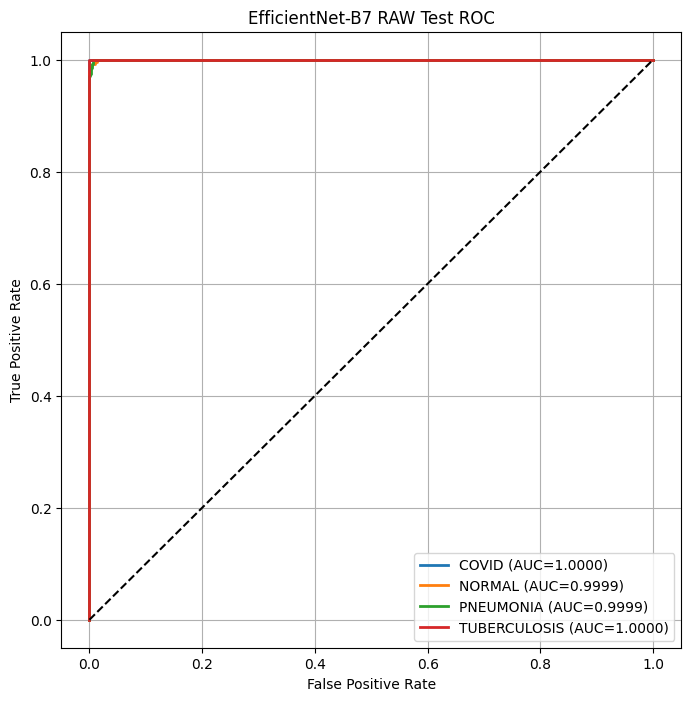

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# -----------------------------
# MODEL
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b7(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/segmantation_chest_x-rays/lungsClassification-raw/best_model_EfNet-B7-RAW.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

# -----------------------------
# Class
# -----------------------------
class_names = [
    "COVID",
    "NORMAL",
    "PNEUMONIA",
    "TUBERCULOSIS"
]

# -----------------------------
# ROC
# -----------------------------
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("Probability Shape :", all_probs.shape)

# One-vs-Rest
y_true = label_binarize(
    all_labels,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,8))

for i in range(len(class_names)):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    print(f"{class_names[i]} AUC = {roc_auc:.6f}")

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC={roc_auc:.4f})"
    )

macro_auc = roc_auc_score(
    y_true,
    all_probs,
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true,
    all_probs,
    average="weighted",
    multi_class="ovr"
)

print(f"\nMacro AUC    : {macro_auc:.6f}")
print(f"Weighted AUC : {weighted_auc:.6f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNet-B7 RAW Test ROC")
plt.legend(loc="lower right")

plt.grid(True)

plt.show()